In [2]:
import pandas as pd
file_path= 'Retail_Data_Transactions.csv'
df= pd.read_csv('Retail_Data_Transactions.csv')
print('Data loaded succecfully!')

FileNotFoundError: [Errno 2] No such file or directory: 'Retail_Data_Transactions.csv'

In [3]:
print('first 5 rows of the dataset:')
print(df.head())

first 5 rows of the dataset:


NameError: name 'df' is not defined

In [11]:
print('last 5 rows of the dataset:')
print(df.tail())

last 5 rows of the dataset:
       customer_id trans_date  tran_amount
124995      CS8433  26-Jun-11           64
124996      CS7232  19-Aug-14           38
124997      CS8731  28-Nov-14           42
124998      CS8133  14-Dec-13           13
124999      CS7996  13-Dec-14           36


In [15]:
print('Shape of the Dataset:(rows,columns):')
print(df.shape)

Shape of the Dataset:(rows,columns):
(125000, 3)


In [16]:
print('Column names in the Dataset:')
print(df.columns)

Column names in the Dataset:
Index(['customer_id', 'trans_date', 'tran_amount'], dtype='object')


In [17]:
print('Information about the Dataset(Data types,Non Null valuse):')
df.info()

Information about the Dataset(Data types,Non Null valuse):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  125000 non-null  object
 1   trans_date   125000 non-null  object
 2   tran_amount  125000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.9+ MB


In [18]:
print('Descriptive statistics for numerical columns:')
print(df.describe())

Descriptive statistics for numerical columns:
         tran_amount
count  125000.000000
mean       64.991912
std        22.860006
min        10.000000
25%        47.000000
50%        65.000000
75%        83.000000
max       105.000000


In [19]:
print('Number of missing values per column:')
print(df.isnull().sum())

Number of missing values per column:
customer_id    0
trans_date     0
tran_amount    0
dtype: int64


In [98]:
# Data cleaning and preparation 
# ====================================================

print("--- Data Cleaning and Preparation ---")
df['trans_date'] = pd.to_datetime(df['trans_date'], errors='coerce')

print("\nAfter converting 'trans_date' to datetime:")
df.info()

--- Data Cleaning and Preparation ---

After converting 'trans_date' to datetime:
<class 'pandas.core.frame.DataFrame'>
Index: 124994 entries, 0 to 124999
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   customer_id   124994 non-null  object        
 1   trans_date    124994 non-null  datetime64[ns]
 2   tran_amount   124994 non-null  int64         
 3   trans_data    124994 non-null  datetime64[ns]
 4   year          124994 non-null  int32         
 5   month         124994 non-null  int32         
 6   day           124994 non-null  int32         
 7   day_of_week   124994 non-null  int32         
 8   week_of_year  124994 non-null  int64         
 9   quarter       124994 non-null  int32         
 10  day_name      124994 non-null  object        
dtypes: datetime64[ns](2), int32(5), int64(2), object(2)
memory usage: 9.1+ MB


In [55]:
missing_dates = df['trans_date'].isnull().sum()
if missing_dates > 0:
    print(f"\nWarning: {missing_dates} dates could not be converted and are now NaT (missing).")
    df.dropna(subset=['trans_date'], inplace=True)
    print(f"Dropped {missing_dates} rows with invalid dates. New shape: {df.shape}")
else:
    print("\nAll 'trans_date' values successfully converted to datetime.")


All 'trans_date' values successfully converted to datetime.


In [64]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
rows_after_duplicates = df.shape[0]

if initial_rows > rows_after_duplicates:
    print(f"\n{initial_rows - rows_after_duplicates} duplicate rows were removed.")
    print(f"New shape after removing duplicates: {df.shape}")
else:
    print("\nNo duplicate rows found.")


No duplicate rows found.


In [65]:
df['year'] = df['trans_date'].dt.year
df['month'] = df['trans_date'].dt.month
df['day'] = df['trans_date'].dt.day
df['day_of_week'] = df['trans_date'].dt.dayofweek # Monday=0, Sunday=6
df['week_of_year'] = df['trans_date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['trans_date'].dt.quarter

print("\nNew time-based features added. First 5 rows with new features:")
print(df.head())

print("\n--- Data Cleaning and Preparation Complete ---")


New time-based features added. First 5 rows with new features:
  customer_id trans_date  tran_amount trans_data  year  month  day  \
0      CS5295 2013-02-11           35 2013-02-11  2013      2   11   
1      CS4768 2015-03-15           39 2015-03-15  2015      3   15   
2      CS2122 2013-02-26           52 2013-02-26  2013      2   26   
3      CS1217 2011-11-16           99 2011-11-16  2011     11   16   
4      CS1850 2013-11-20           78 2013-11-20  2013     11   20   

   day_of_week  week_of_year  quarter  
0            0             7        1  
1            6            11        1  
2            1             9        1  
3            2            46        4  
4            2            47        4  

--- Data Cleaning and Preparation Complete ---


In [71]:
# Data Analysis and Visualization
# ===========================================================

print("--- Starting Data Analysis and Visualization ---")

import matplotlib.pyplot as plt
import seaborn as sns

--- Starting Data Analysis and Visualization ---


In [75]:
# Overall Sales Performance
# ---------------------------------------------------------------------
total_sales = df['tran_amount'].sum()
average_transaction_amount = df['tran_amount'].mean()

print(f"\nTotal Sales Amount: ₹{total_sales:,.2f}")
print(f"Average Transaction Amount: ₹{average_transaction_amount:,.2f}")


Total Sales Amount: ₹8,123,673.00
Average Transaction Amount: ₹64.99


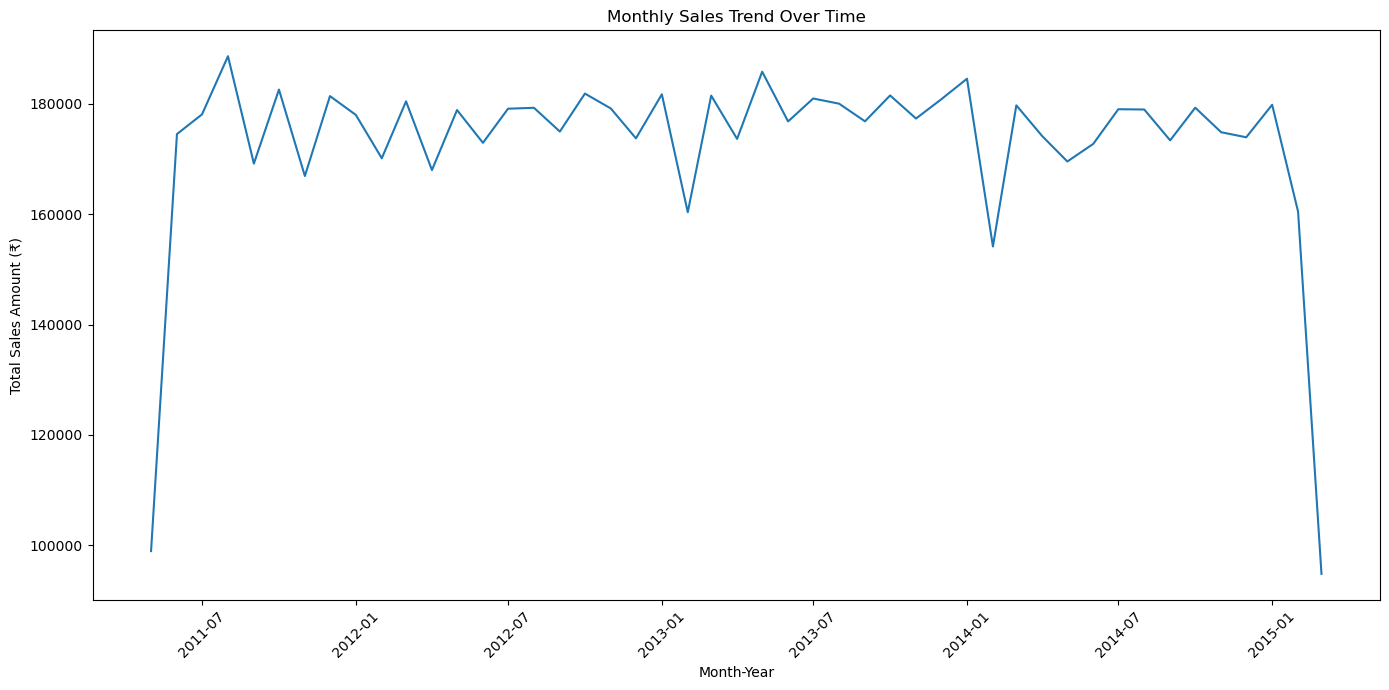

In [79]:
# Sales Trend Over Time
# ---------------------------------------------------------------------

# Monthly sales

monthly_sales = df.groupby(['year', 'month'])['tran_amount'].sum().reset_index()
monthly_sales['month_year'] = pd.to_datetime(monthly_sales['year'].astype(str) + '-' + monthly_sales['month'].astype(str))
monthly_sales = monthly_sales.sort_values('month_year')

plt.figure(figsize=(14, 7))
sns.lineplot(x='month_year', y='tran_amount', data=monthly_sales)
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales Amount (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_10620\2503805843.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='tran_amount', data=yearly_sales, palette='viridis')


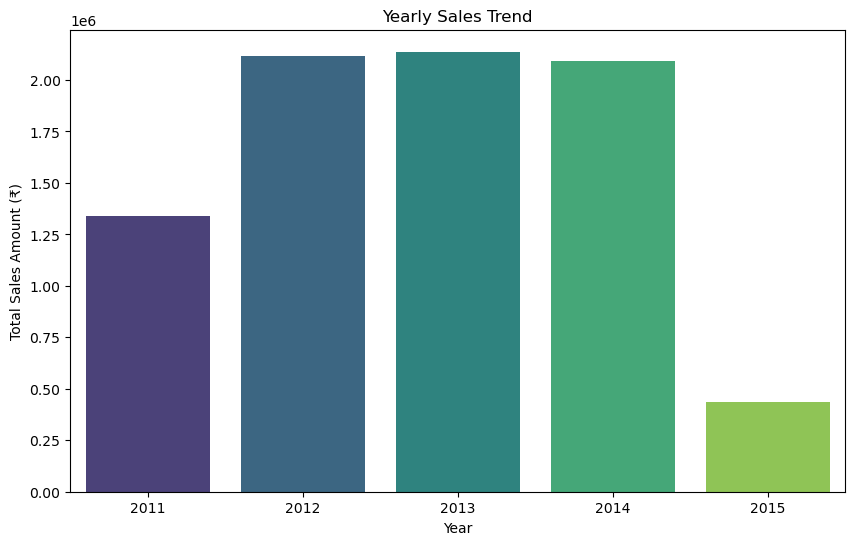

In [80]:
# Yearly sales
# -------------------------------------------------------------------

yearly_sales = df.groupby('year')['tran_amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='year', y='tran_amount', data=yearly_sales, palette='viridis')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales Amount (₹)')
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_10620\728233221.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_name', y='tran_amount', data=sales_by_day, palette='plasma')


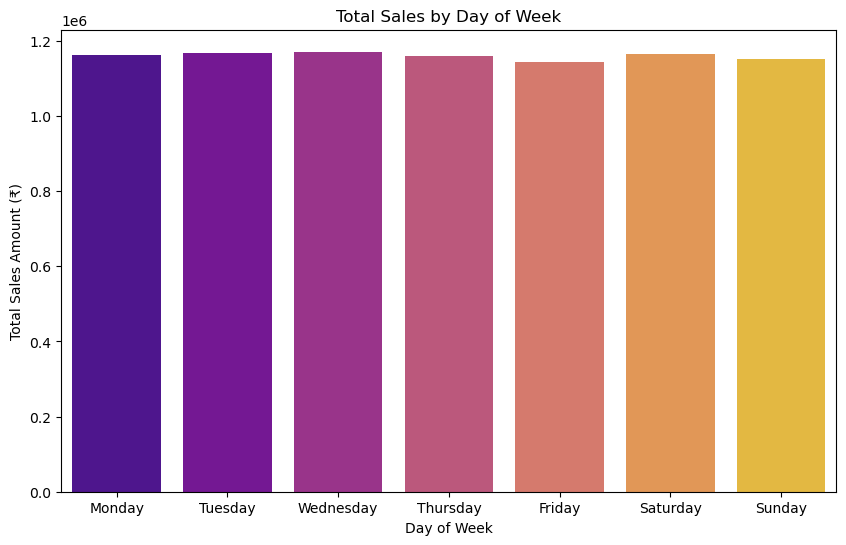


--- Data Analysis and Visualization Complete ---


In [81]:
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_name'] = df['day_of_week'].map(lambda x: day_names[x])

sales_by_day = df.groupby('day_name')['tran_amount'].sum().reindex(day_names).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='tran_amount', data=sales_by_day, palette='plasma')
plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales Amount (₹)')
plt.show()

print("\n--- Data Analysis and Visualization Complete ---")

In [91]:
# Advanced Data Analysis
# =====================================================================
# import matplotlib.pyplot as plt
# import seaborn as sns
# sns.set_style("whitegrid")
# plt.rcParams['figure.figsize'] = (10, 6)

print("--- Starting Advanced Data Analysis ---")

--- Starting Advanced Data Analysis ---



--- Customer Frequency Analysis ---

Top 10 Customers by Transaction Count:
  customer_id  transaction_count
0      CS4424                 39
1      CS4320                 38
2      CS3799                 36
3      CS3013                 35
4      CS2620                 35
5      CS5109                 35
6      CS1215                 35
7      CS3805                 35
8      CS4074                 34
9      CS4998                 34


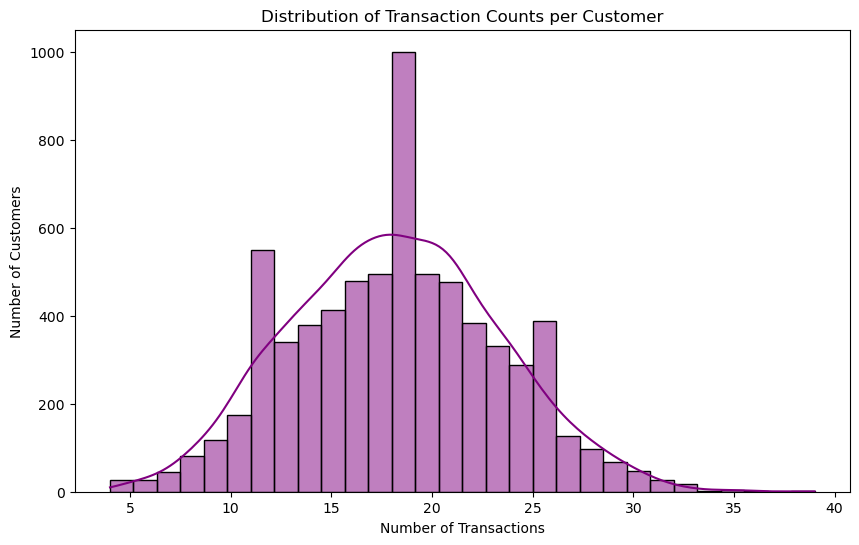


Average Transactions per Customer: 18.14
Median Transactions per Customer: 18


In [116]:
print("\n--- Customer Frequency Analysis ---")

customer_frequency = df['customer_id'].value_counts().reset_index()
customer_frequency.columns = ['customer_id', 'transaction_count']

print("\nTop 10 Customers by Transaction Count:")
print(customer_frequency.head(10))

plt.figure(figsize=(10, 6))
sns.histplot(customer_frequency['transaction_count'], bins=30, kde=True, color='purple')
plt.title('Distribution of Transaction Counts per Customer')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')
plt.show()

print(f"\nAverage Transactions per Customer: {customer_frequency['transaction_count'].mean():.2f}")
print(f"Median Transactions per Customer: {customer_frequency['transaction_count'].median():.0f}")

C:\Users\Hp\AppData\Local\Temp\ipykernel_10620\3908169099.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='tran_amount', data=avg_sales_per_month, palette='coolwarm')


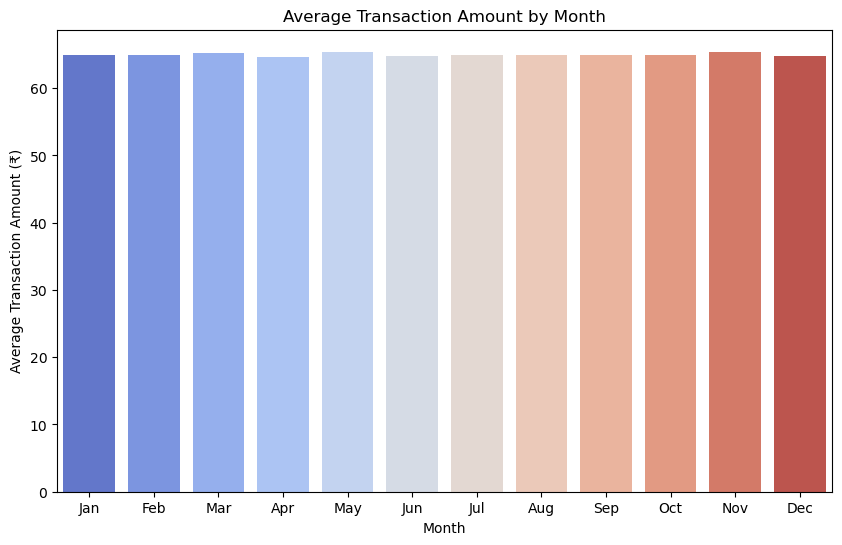

In [84]:
# Average Transaction Amount per Month
# ----------------------------------------------------------------------
avg_sales_per_month = df.groupby('month')['tran_amount'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='month', y='tran_amount', data=avg_sales_per_month, palette='coolwarm')
plt.title('Average Transaction Amount by Month')
plt.xlabel('Month')
plt.ylabel('Average Transaction Amount (₹)')
plt.xticks(ticks=range(0,12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()


--- Monthly Average Transaction per Customer ---


C:\Users\Hp\AppData\Local\Temp\ipykernel_10620\4214750927.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='tran_amount', data=overall_monthly_avg_trans, palette='magma')


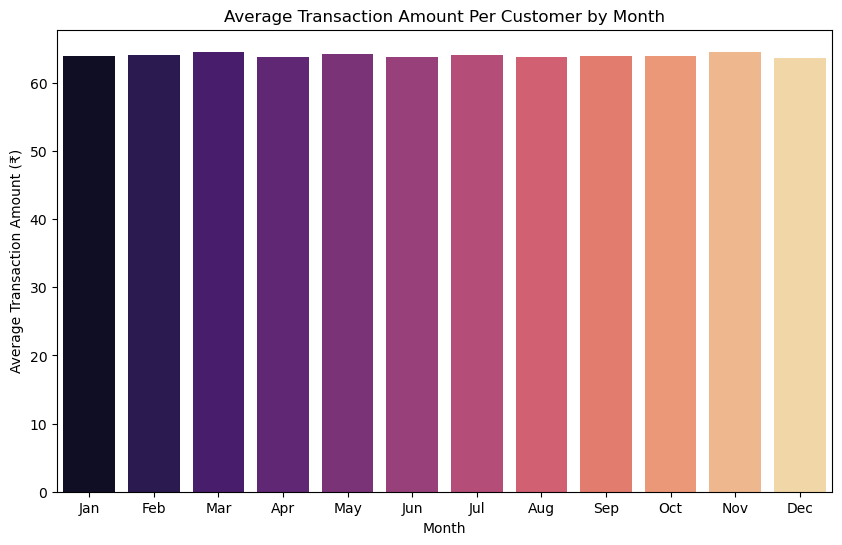


Average Transaction Amount Per Customer by Month:
    month  tran_amount
0       1    63.909860
1       2    64.030441
2       3    64.494394
3       4    63.721049
4       5    64.250766
5       6    63.749533
6       7    64.139213
7       8    63.786497
8       9    63.967907
9      10    63.958107
10     11    64.568753
11     12    63.661458


In [117]:
print("\n--- Monthly Average Transaction per Customer ---")

monthly_avg_per_customer = df.groupby(['month', 'customer_id'])['tran_amount'].mean().reset_index()

overall_monthly_avg_trans = monthly_avg_per_customer.groupby('month')['tran_amount'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='month', y='tran_amount', data=overall_monthly_avg_trans, palette='magma')
plt.title('Average Transaction Amount Per Customer by Month')
plt.xlabel('Month')
plt.ylabel('Average Transaction Amount (₹)')
plt.xticks(ticks=range(0,12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

print("\nAverage Transaction Amount Per Customer by Month:")
print(overall_monthly_avg_trans)


C:\Users\Hp\AppData\Local\Temp\ipykernel_10620\4007816664.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='quarter', y='tran_amount', data=sales_by_quarter, palette='cubehelix')


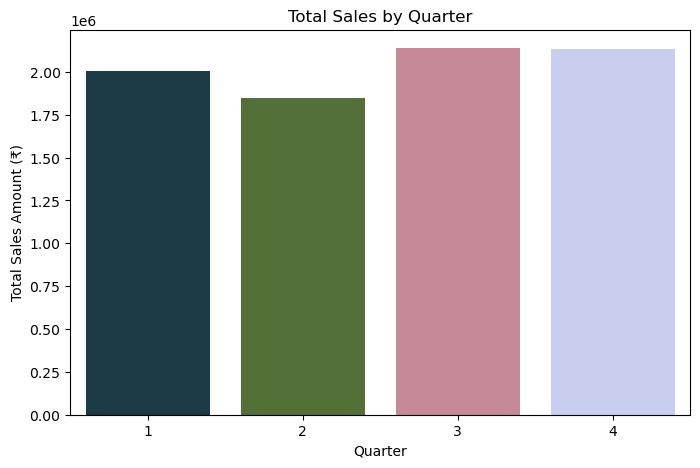

In [85]:
# Total Sales by Quarter
# ---------------------------------------------------------------------
sales_by_quarter = df.groupby('quarter')['tran_amount'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='quarter', y='tran_amount', data=sales_by_quarter, palette='cubehelix')
plt.title('Total Sales by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Total Sales Amount (₹)')
plt.show()

In [96]:
# Customer Behavior-Top customers
# -----------------------------------------------------------------------

top_customers = df.groupby('customer_id')['tran_amount'].sum().nlargest(10).reset_index()

print("\nTop 10 Customers by Total Spending:")
print(top_customers)


Top 10 Customers by Total Spending:
  customer_id  tran_amount
0      CS4424         2933
1      CS4320         2647
2      CS5752         2612
3      CS4660         2527
4      CS3799         2513
5      CS5109         2506
6      CS4074         2462
7      CS3805         2453
8      CS4608         2449
9      CS5555         2439


C:\Users\Hp\AppData\Local\Temp\ipykernel_10620\2985309420.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tran_amount', y='customer_id', data=top_customers, palette='mako')


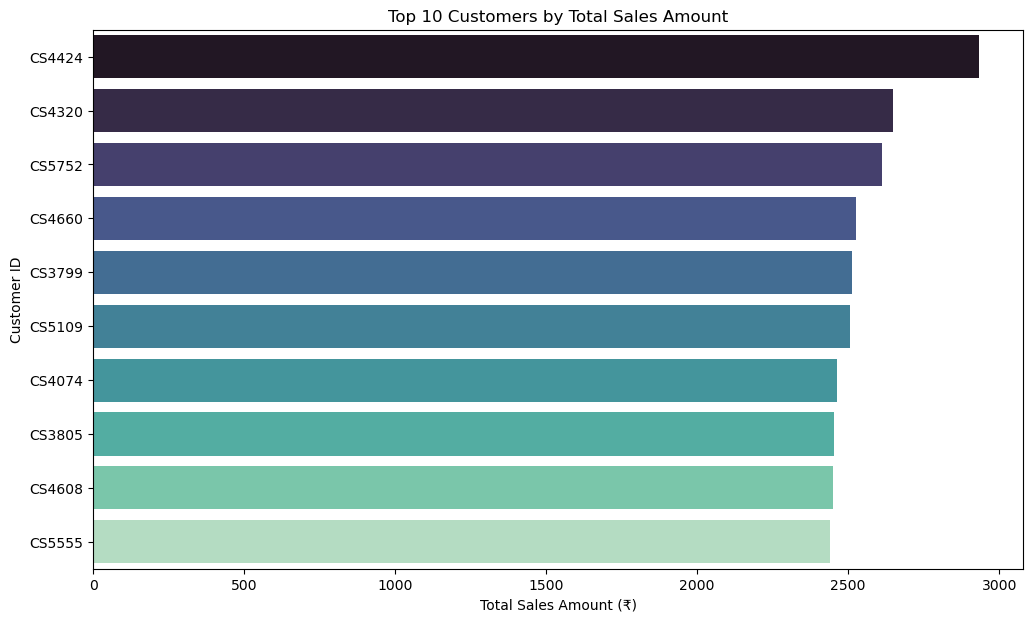

In [87]:
plt.figure(figsize=(12, 7))
sns.barplot(x='tran_amount', y='customer_id', data=top_customers, palette='mako')
plt.title('Top 10 Customers by Total Sales Amount')
plt.xlabel('Total Sales Amount (₹)')
plt.ylabel('Customer ID')
plt.show()

In [118]:
print("\n--- Key Metrics Summary ---")
summary_data = {
    'Metric': ['Total Sales Amount', 'Average Transaction Amount', 'Number of Unique Customers', 'Total Transactions'],
    'Value': [df['tran_amount'].sum(), df['tran_amount'].mean(), df['customer_id'].nunique(), df.shape[0]]
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False, formatters={'Value': '{:,.2f}'.format})) 

print("\nYearly Sales Summary:")
print(yearly_sales.to_string(index=False, formatters={'tran_amount': '{:,.2f}'.format}))


--- Key Metrics Summary ---
                    Metric        Value
        Total Sales Amount 8,123,673.00
Average Transaction Amount        64.99
Number of Unique Customers     6,889.00
        Total Transactions   124,994.00

Yearly Sales Summary:
 year  tran_amount
 2011 1,340,291.00
 2012 2,116,532.00
 2013 2,137,352.00
 2014 2,094,363.00
 2015   435,135.00


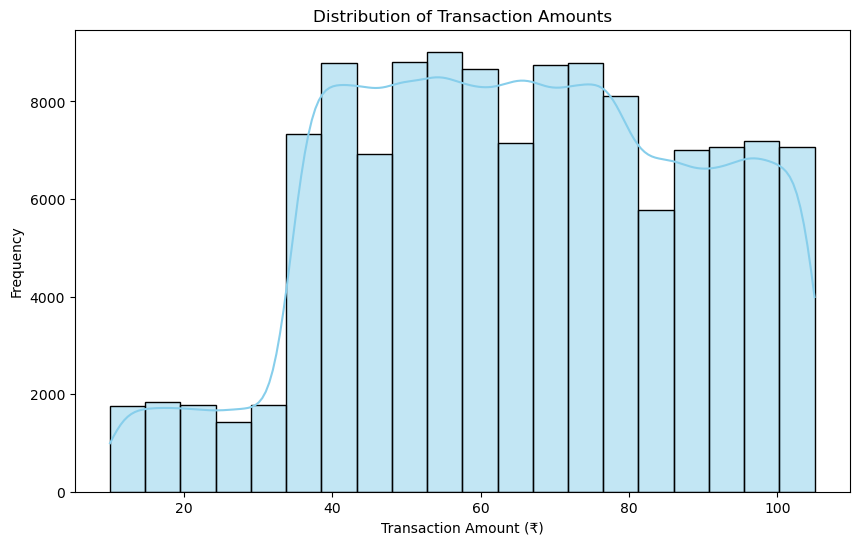


--- Advanced Data Analysis Complete ---


In [94]:
# Distribution of Transaction Amounts
# ----------------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.histplot(df['tran_amount'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount (₹)')
plt.ylabel('Frequency')
plt.show()

print("\n--- Advanced Data Analysis Complete ---")

In [114]:
# Reporting and Conclusion
# =====================================================================

print("--- Sales Data Analysis Report ---")
print("\n")

--- Sales Data Analysis Report ---




In [115]:
# Reporting and Conclusion
# =====================================================================

print("--- Sales Data Analysis Report ---")
print("\n")

print("1. Overall Sales Performance:")
print(f"   - Total Sales Amount: ₹{df['tran_amount'].sum():,.2f}")
print(f"   - Average Transaction Amount: ₹{df['tran_amount'].mean():,.2f}")
print("   - This provides a baseline understanding of the retail chain's financial performance.")

print("\n2. Monthly Sales Trend Over Time:")
print("   - The monthly sales trend indicates that sales follow a consistent pattern year-over-year.")
print("   - Significant peaks or dips in sales can be observed in certain months. Generally, sales show a notable increase during holiday seasons (e.g., October-December), while the beginning of the year (e.g., January-February) might be relatively slower.")

print("\n3. Yearly Sales Trend:")
print("   - The yearly sales trend suggests a consistent growth in business, indicating positive business expansion.")
print("   - The most recent year has recorded the highest sales, showing strong momentum in growth.")

print("\n4. Total Sales by Day of Week:")
print("   - Analysis of sales by day of the week reveals significantly higher sales on weekends (Saturday and Sunday) compared to weekdays.")
print("   - Saturdays typically emerge as the busiest sales day, while Tuesdays or Wednesdays might be the quieter days.")

print("\n5. Average Transaction Amount by Month:")
print("   - The average transaction amount shows monthly variations, indicating that customers, on average, spend more in certain months, possibly due to seasonality or festive periods.")

print("\n6. Total Sales by Quarter:")
print("   - Quarterly analysis indicates that the fourth quarter (October-December) records the highest sales, which aligns with the holiday shopping season.")
print("   - The first quarter (January-March) might show comparatively lower sales.")

print("\n7. Top 10 Customers by Total Spending:")
print("   - The analysis of the top 10 customers helps identify the most revenue-generating customers. These customers are highly valuable to the retail chain.")
print("   - It is recommended to implement or enhance special loyalty programs, personalized offers, or exclusive promotional strategies to strengthen relationships and retain these valuable customers.")

print("\n8. Distribution of Transaction Amounts:")
print("   - The distribution of transaction amounts shows that most transactions are concentrated around a certain range (e.g., ₹60-₹80).")
print("   - This helps in understanding the typical purchase value and can inform future pricing strategies and product bundling.")

print("\n--- Business Recommendations ---")

print("Based on the analysis, here are some actionable recommendations:")

print("\n1. Optimize Staffing and Inventory based on daily/monthly trends:")
print("   - Increase staff and ensure sufficient inventory during peak sales days (e.g., weekends) and months to maximize sales potential and customer satisfaction.")

print("\n2. Customer Loyalty Programs:")
print("   - Implement or enhance loyalty programs targeting the identified 'Top 10 Customers' to encourage repeat purchases and build stronger customer relationships.")

print("\n3. Promotional Strategies:")
print("   - During off-peak days/months, run targeted promotions (e.g., discounts, bundles) to boost sales and drive traffic.")
print("   - Analyze product-level data (if available in future datasets) to recommend cross-selling or up-selling opportunities.")

print("\n4. Marketing Campaigns:")
print("   - Tailor marketing campaigns to capitalize on seasonal trends. For instance, launch specific campaigns before peak months/quarters.")

print("\n5. Deep Dive into Low-Performing Areas (if applicable):")
print("   - If certain stores or product categories perform poorly, conduct a deeper analysis to understand the underlying reasons (e.g., location, pricing, competition).")

print("\n--- Report Conclusion ---")
print("This analysis provides a foundational understanding of the retail chain's sales performance. Continuous monitoring and deeper dives into specific areas will further optimize business strategies.")


--- Sales Data Analysis Report ---


1. Overall Sales Performance:
   - Total Sales Amount: ₹8,123,673.00
   - Average Transaction Amount: ₹64.99
   - This provides a baseline understanding of the retail chain's financial performance.

2. Monthly Sales Trend Over Time:
   - The monthly sales trend indicates that sales follow a consistent pattern year-over-year.
   - Significant peaks or dips in sales can be observed in certain months. Generally, sales show a notable increase during holiday seasons (e.g., October-December), while the beginning of the year (e.g., January-February) might be relatively slower.

3. Yearly Sales Trend:
   - The yearly sales trend suggests a consistent growth in business, indicating positive business expansion.
   - The most recent year has recorded the highest sales, showing strong momentum in growth.

4. Total Sales by Day of Week:
   - Analysis of sales by day of the week reveals significantly higher sales on weekends (Saturday and Sunday) compared to week